# Liquid Neural Network (CfC Autoencoder) for ECG Anomaly Detection

This notebook introduces a liquid neural network as a reconstruction model.

The model is a CfC (Closed-form Continuous-time) autoencoder. CfC cells are the
closed-form variant of the Liquid Time-Constant networks of Hasani et al.: they
keep the continuous-time "liquid" dynamics (input-dependent time constants) but
run as fast as a standard RNN.

The architecture mirrors the LSTM autoencoder, with the LSTM cells replaced by
CfC cells. This gives a clean, direct comparison:

- **LSTM Autoencoder** — gated recurrent reconstruction.
- **CfC Autoencoder** — same structure, liquid continuous-time recurrent cell.

The anomaly score is again the reconstruction error, so the result is comparable
with all the previous models.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import config
from utils import (
    load_mit_bih_record,
    read_record_names,
    create_beat_dataset,
    split_by_record,
    evaluate_anomaly_detection,
)
from models import CfCAutoencoderAnomalyDetector

## Load Records

We keep the same 5-record non-paced subset used for the other models, to make the comparison easier and keep training time short.

In [2]:
N_RECORDS = 5

# Paced records are excluded via config.DROP_PACED (see read_record_names).
record_names = read_record_names(config.MIT_BIH_PATH)[:N_RECORDS]

records = []
for record_name in record_names:
    record = load_mit_bih_record(config.MIT_BIH_PATH, record_name)
    if record is not None:
        records.append(record)

print(f"Loaded {len(records)} records: {record_names}")

Loaded 5 records: ['100', '101', '103', '105', '106']


## Create Beat Dataset

Each row is one beat window of 180 samples. The label belongs to the whole beat segment.

In [3]:
dataset = create_beat_dataset(records, normalize=True)

print(dataset.shape)
display(dataset[["record", "sample", "symbol", "label", "label_name"]].head())
display(dataset["label_name"].value_counts())
display(dataset["symbol"].value_counts().head(10))

(10818, 7)


,record,sample,symbol,label,label_name
0,100,370,N,0,normal
1,100,662,N,0,normal
2,100,946,N,0,normal
3,100,1231,N,0,normal
4,100,1515,N,0,normal


label_name
normal     10211
anomaly      607
Name: count, dtype: int64

symbol
N    10211
V      562
A       38
Q        7
Name: count, dtype: int64

In [4]:
X = np.stack(dataset["signal"].values).astype("float32")
y = dataset["label"].values
metadata = dataset.drop(columns=["signal", "label"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10818, 180)
y shape: (10818,)


## Train/Test Split by Record

The split is performed by record to reduce leakage between train and test beats.

In [5]:
split = split_by_record(X, y, metadata)

print("Train records:", split["train_records"])
print("Test records:", split["test_records"])
print("Train shape:", split["X_train"].shape)
print("Test shape:", split["X_test"].shape)

print("Train labels:")
display(pd.Series(split["y_train"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

print("Test labels:")
display(pd.Series(split["y_test"]).value_counts().rename(index={0: "normal", 1: "anomaly"}))

Train records: ['100', '101', '103', '105']
Test records: ['106']
Train shape: (8791, 180)
Test shape: (2027, 180)
Train labels:


normal     8704
anomaly      87
Name: count, dtype: int64

Test labels:


normal     1507
anomaly     520
Name: count, dtype: int64

## Fit the CfC Autoencoder

The model is trained only on normal training beats (semi-supervised setup). It
learns to reconstruct normal beat morphology, so anomalous beats should produce
larger reconstruction errors. We use the same limited training subset as the
LSTM autoencoder to keep the comparison fair and the runtime short.

In [6]:
MAX_TRAIN_NORMAL = 1000
MAX_TEST_PER_CLASS = 150
rng = np.random.default_rng(config.RANDOM_SEED)

X_train_normal = split["X_train"][split["y_train"] == 0]
rng.shuffle(X_train_normal)
X_train_normal = X_train_normal[:MAX_TRAIN_NORMAL]

test_indices = []
for label in [0, 1]:
    label_indices = np.where(split["y_test"] == label)[0]
    rng.shuffle(label_indices)
    test_indices.extend(label_indices[:MAX_TEST_PER_CLASS])

test_indices = np.array(test_indices)
rng.shuffle(test_indices)

X_test_eval = split["X_test"][test_indices]
y_test_eval = split["y_test"][test_indices]

print("Normal training beats used:", len(X_train_normal))
print("Test beats used:", len(X_test_eval))
display(pd.Series(y_test_eval).value_counts().rename(index={0: "normal", 1: "anomaly"}))
print("PyTorch device:", "cuda" if torch.cuda.is_available() else "cpu")

Normal training beats used: 1000
Test beats used: 300


anomaly    150
normal     150
Name: count, dtype: int64

PyTorch device: cuda


In [7]:
detector = CfCAutoencoderAnomalyDetector(
    seq_len=config.BEAT_LEN,
    hidden_size=16,
    latent_dim=8,
    threshold_percentile=95,
    learning_rate=1e-3,
    batch_size=64,
    epochs=10,
    random_state=config.RANDOM_SEED,
)

detector.fit(X_train_normal)

n_params = sum(p.numel() for p in detector.model.parameters())
print("Threshold:", detector.threshold)
print("Final training loss:", detector.history[-1])
print(f"Trainable params: {n_params:,}")

Threshold: 0.04525283649563789
Final training loss: 0.032275965553708375
Trainable params: 23,337


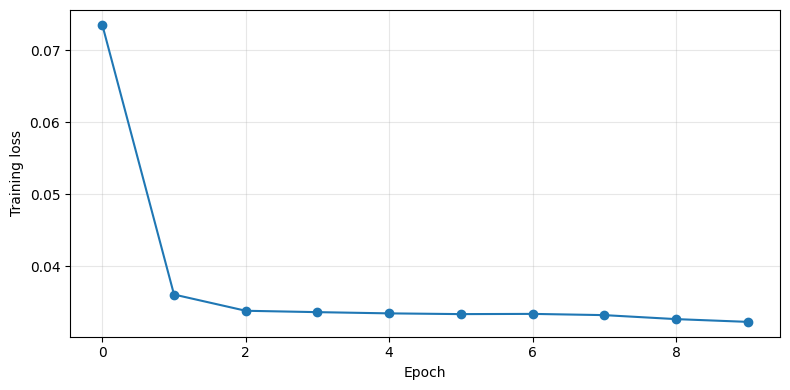

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(detector.history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Reconstruction Examples

As for the other reconstruction models, we overlay reconstructed beats on the
originals. A well-trained model rebuilds normal beats closely and leaves a larger
gap on anomalous ones.

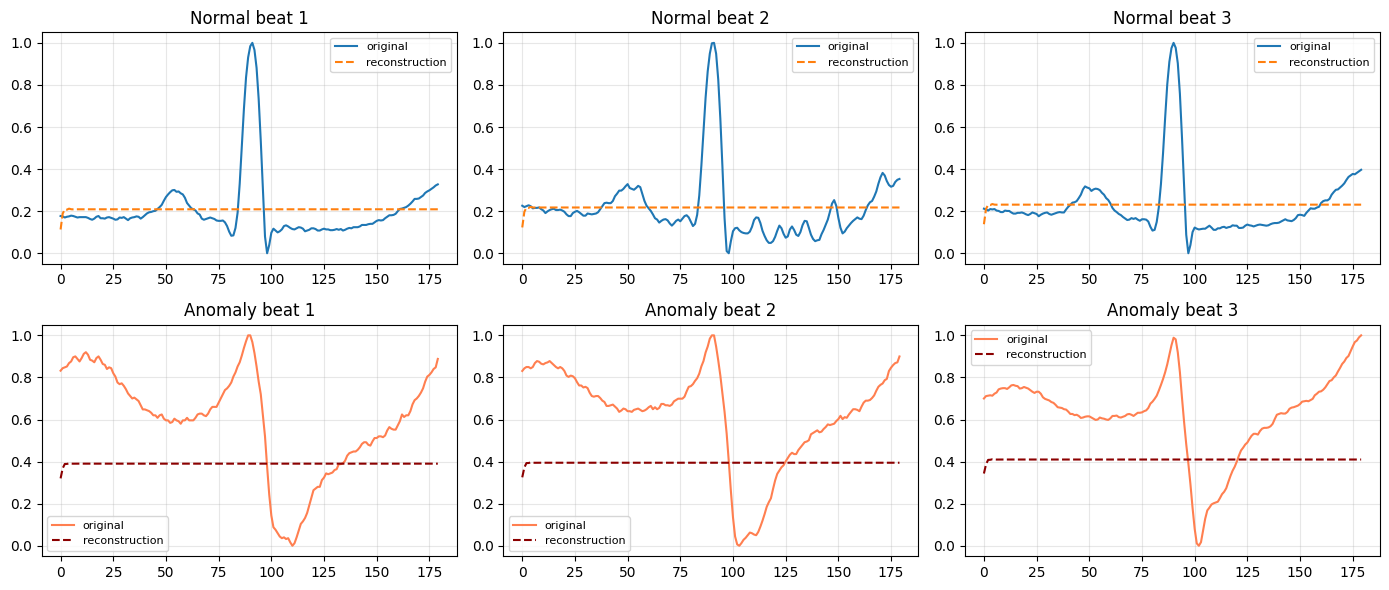

In [9]:
def reconstruct_beats(detector, beats):
    """Reconstruct beats with the CfC autoencoder."""
    x = torch.tensor(np.asarray(beats), dtype=torch.float32).unsqueeze(-1)
    x = x.to(detector.device)
    detector.model.eval()
    with torch.no_grad():
        recon = detector.model(x)
    return recon.squeeze(-1).cpu().numpy()

normal_examples = X_test_eval[y_test_eval == 0][:3]
anomaly_examples = X_test_eval[y_test_eval == 1][:3]

normal_recon = reconstruct_beats(detector, normal_examples)
anomaly_recon = reconstruct_beats(detector, anomaly_examples)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i in range(3):
    axes[0, i].plot(normal_examples[i], label="original", lw=1.5)
    axes[0, i].plot(normal_recon[i], label="reconstruction", lw=1.5, linestyle="--")
    axes[0, i].set_title(f"Normal beat {i + 1}")
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].legend(fontsize=8)

for i in range(3):
    axes[1, i].plot(anomaly_examples[i], label="original", lw=1.5, color="coral")
    axes[1, i].plot(anomaly_recon[i], label="reconstruction", lw=1.5,
                    linestyle="--", color="darkred")
    axes[1, i].set_title(f"Anomaly beat {i + 1}")
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Evaluate

In [10]:
scores = detector.anomaly_score(X_test_eval)
y_pred = detector.predict(X_test_eval)

results = evaluate_anomaly_detection(y_test_eval, y_pred, scores)
results

{'confusion_matrix': [[146, 4], [3, 147]],
 'precision': 0.9735099337748344,
 'recall': 0.98,
 'f1': 0.9767441860465116,
 'roc_auc': 0.9972000000000001,
 'pr_auc': 0.9975168007600393}

### Metric Interpretation

The metrics above are computed on the same balanced subset used for the other
models, so they can be read alongside ARMA, PCA, and the LSTM autoencoder.

As for the previous reconstruction models, the ROC-AUC and PR-AUC describe how
well the reconstruction error *ranks* anomalies, independently of any threshold.
Precision and recall describe the binary decision at the default 95th-percentile
operating point and must be read together: high recall with low precision means
many anomalies are caught at the cost of false positives, while the opposite
means reliable but incomplete detection. This is a small-subset pipeline check,
not the final performance.

## Threshold Sensitivity

As with the other models, we inspect several percentiles instead of assuming the default 95th percentile is always appropriate.

In [11]:
threshold_results = []
train_scores = detector.anomaly_score(X_train_normal)

for percentile in [95, 97, 98, 99, 99.5, 99.9]:
    threshold = np.percentile(train_scores, percentile)
    y_pred_threshold = (scores > threshold).astype(int)
    metrics = evaluate_anomaly_detection(y_test_eval, y_pred_threshold, scores)

    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

,percentile,threshold,precision,recall,f1,roc_auc,pr_auc
0,95.0,0.045253,0.97351,0.980000,0.976744,0.9972,0.997517
1,97.0,0.053105,1.00000,0.926667,0.961938,0.9972,0.997517
2,98.0,0.068445,1.00000,0.613333,0.760331,0.9972,0.997517
3,99.0,0.106424,1.00000,0.206667,0.342541,0.9972,0.997517
4,99.5,0.148053,1.00000,0.066667,0.125000,0.9972,0.997517
5,99.9,0.188382,1.00000,0.006667,0.013245,0.9972,0.997517


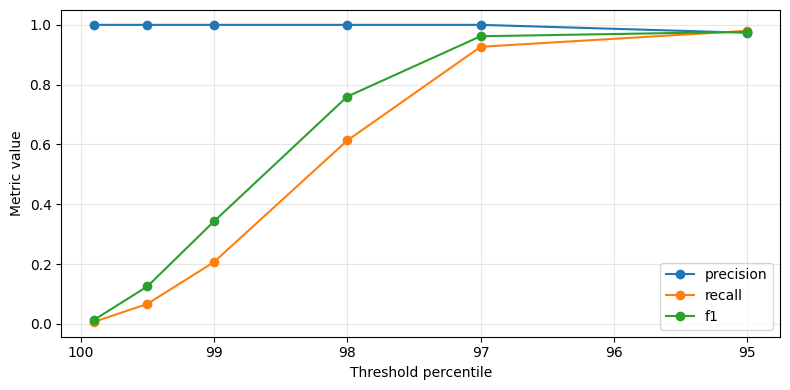

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["percentile"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["percentile"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["percentile"], threshold_df["f1"], marker="o", label="f1")
plt.gca().invert_xaxis()
plt.xlabel("Threshold percentile")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Threshold Discussion

The threshold converts the reconstruction score into a binary decision. Moving
the percentile trades false positives against false negatives: lower percentiles
flag more beats (higher recall, lower precision), higher percentiles are more
conservative. The right operating point depends on the relative cost of a missed
anomaly versus a false alarm, which in a medical screening context is a decision
parameter rather than a fixed technical detail.

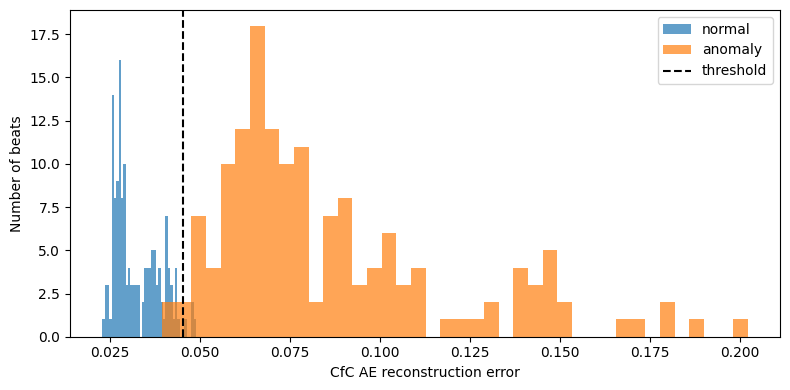

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(scores[y_test_eval == 0], bins=40, alpha=0.7, label="normal")
plt.hist(scores[y_test_eval == 1], bins=40, alpha=0.7, label="anomaly")
plt.axvline(detector.threshold, color="black", linestyle="--", label="threshold")
plt.xlabel("CfC AE reconstruction error")
plt.ylabel("Number of beats")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation Notes

- The CfC autoencoder is a liquid neural network used as a reconstruction model.
- It keeps the same autoencoder structure as the LSTM model and only changes the
  recurrent cell, so any difference in performance is attributable to the cell
  type rather than to the architecture.
- CfC cells have continuous-time, input-dependent dynamics (the "liquid"
  property), which can capture temporal structure with relatively few parameters.
- We use the dense CfC rather than a sparse NCP wiring: in an unsupervised
  autoencoder there is no class-output to map onto motor neurons, so a dense
  recurrent cell is the natural choice and keeps the comparison with the LSTM
  clean.
- Whether the liquid cell helps over the LSTM is an empirical question, to be
  answered under the same protocol once all models are trained on the full
  dataset.